使用纯Model达到期望形变，对实验结果的分析

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [70]:
# plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)
def plot_loss_and_traj(loss_np, ur_data, dot_soft_np):
    rob_pose_x = ur_data['actual_TCP_pose_0'].to_numpy()
    rob_pose_y = ur_data['actual_TCP_pose_1'].to_numpy()
    step_num = loss_np.shape[0]
    plot_step_num = 100

    # plot loss curve
    fig1 = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig1)

    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    filtered_colors = [color for color in colors if not (
        color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    step_num = loss_np.shape[0]
    axs_loss = fig1.add_subplot(gs[0, :])
    for i in range(loss_np.shape[1]):
        axs_loss.plot(loss_np[:, i], marker='.', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Marker {i+1}')
    axs_loss.plot(np.sum(loss_np, axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, plot_step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(10))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    axs_loss.legend(loc='upper right', fontsize=12)
    axs_loss.grid(True)

    # plot trajectory
    fig2 = plt.figure(figsize=(10, 4), dpi=100)
    gs = GridSpec(1, 5, figure=fig2)

    indices = np.linspace(0, len(rob_pose_x)-1, step_num, dtype=int)
    rows = np.arange(step_num)
    norm = plt.Normalize(rows.min(), rows.max())
    colors = plt.cm.plasma(norm(rows))

    axs_rob_mov = fig2.add_subplot(gs[0, 0])
    rob_pose_xy = np.stack([rob_pose_x[indices], rob_pose_y[indices]], axis=1).reshape(-1, 1, 2)
    segments = np.concatenate([rob_pose_xy[:-1], rob_pose_xy[1:]], axis=1)
    lc = LineCollection(segments * 1000, colors=colors, norm=norm)
    axs_rob_mov.add_collection(lc)
    axs_rob_mov.autoscale()
    axs_rob_mov.set_title('Robot Tool Movement', fontsize=14, fontname='Times New Roman')
    # axs_rob_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
    # axs_rob_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_rob_mov.set_aspect('equal', 'datalim')
    axs_rob_mov.grid(True)

    # # 设置比例尺的字体和大小
    # fontprops = fm.FontProperties(size=12)

    # # 比例尺长度; 比例尺标签; 比例尺位置; 内边距; 比例尺颜色; 去掉边框; 比例尺的厚度
    # scalebar = AnchoredSizeBar(axs_rob_mov.transData, 0.002, '2 mm', loc='upper right', pad=0.5, color='black', frameon=False, size_vertical=1.e-5, fontproperties=fontprops)

    # # 添加比例尺到图中
    # axs_rob_mov.add_artist(scalebar)


    axs_dot_mov_list = []
    for i in range(POINTS_NUM):
        axs_dot_mov = fig2.add_subplot(gs[0, i+1])
        dots_soft = np.stack([dot_soft_np[:, 2*i+1], dot_soft_np[:, 2*i]], axis=1).reshape(-1, 1, 2)
        segments = np.concatenate([dots_soft[:-1], dots_soft[1:]], axis=1)
        lc = LineCollection(segments * 1000., colors=colors, norm=norm)
        axs_dot_mov.add_collection(lc)
        axs_dot_mov.autoscale()
        # axs_dot_mov.plot(dot_soft_np[:, 2*i+1], dot_soft_np[:, 2*i], marker=',', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Dot {i+1}')
        axs_dot_mov.set_title(f'Marker {i+1} Movement', fontsize=14, fontname='Times New Roman')
        # axs_dot_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
        # axs_dot_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
        axs_dot_mov.set_aspect('equal', 'datalim')
        axs_dot_mov.grid(True)

        # # 比例尺长度; 比例尺标签; 比例尺位置; 内边距; 比例尺颜色; 去掉边框; 比例尺的厚度
        # scalebar = AnchoredSizeBar(axs_dot_mov.transData, 0.002, '2 mm', loc='upper right', pad=0.5, color='black', frameon=False, size_vertical=1.e-5, fontproperties=fontprops)

        # # 添加比例尺到图中
        # axs_dot_mov.add_artist(scalebar)

        axs_dot_mov_list.append(axs_dot_mov)

    plt.tight_layout()

---
只用了Model提供的Loss梯度,机器人最大动作量为3.e-4

In [15]:
POINTS_NUM:int = 4
num:int = 5
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


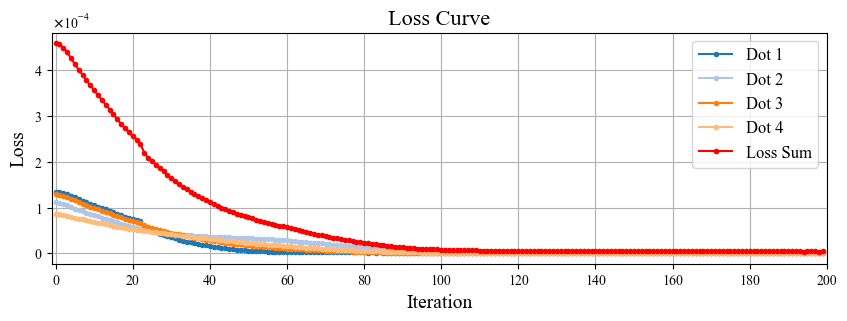

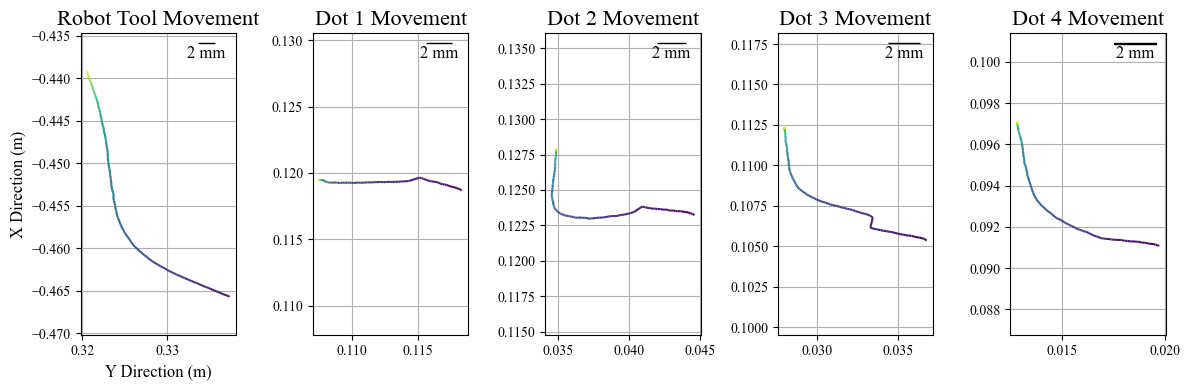

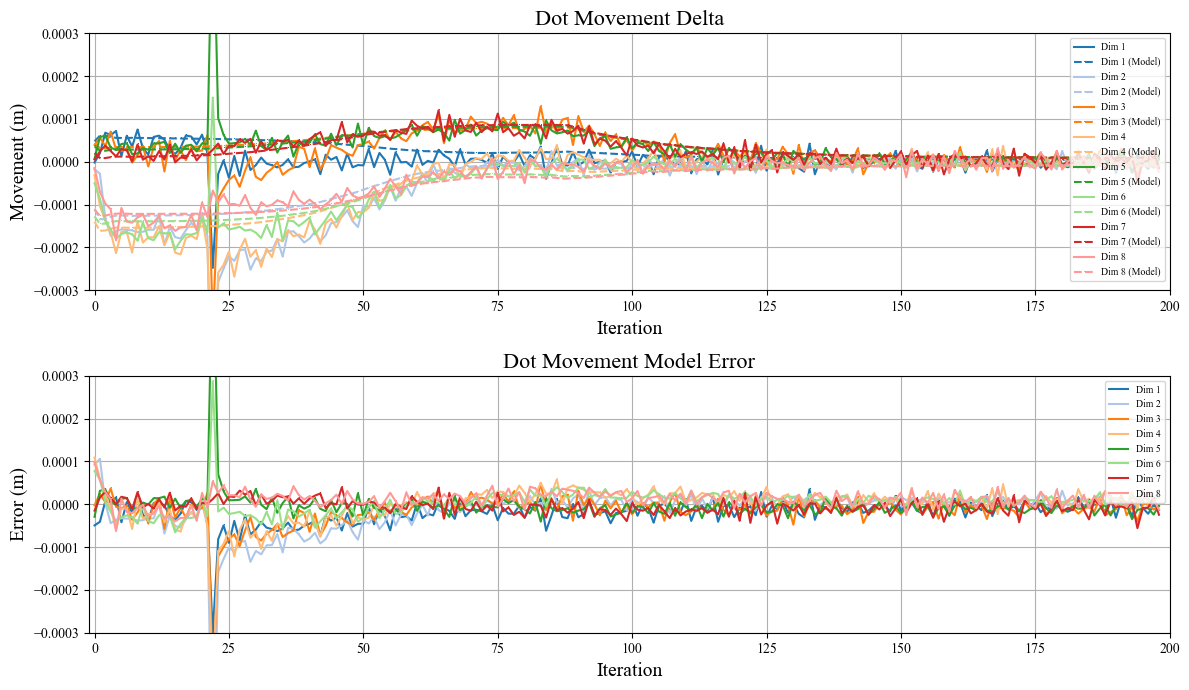

In [18]:
plot_loss_and_traj(loss_np, ur_data, dot_soft_np)

colors = plt.cm.tab20.colors

fig = plt.figure(figsize=(12, 7), dpi=100)
gs = GridSpec(2, 1, figure=fig)

axs_data = fig.add_subplot(gs[0, :])
for i in range(2*POINTS_NUM):
    axs_data.plot(delta_pos[1:, i], marker=',', linestyle='-', color=colors[i % len(colors)], label=f'Dim {i+1}')
    axs_data.plot(delta_pos_model[1:, i], marker=',', linestyle='--', color=colors[i % len(colors)], label=f'Dim {i+1} (Model)')
axs_data.set_title('Dot Movement Delta', fontsize=16, fontname='Times New Roman')
axs_data.set_xlabel('Iteration', fontsize=14, fontname='Times New Roman')
axs_data.set_ylabel('Movement (m)', fontsize=14, fontname='Times New Roman')

axs_error = fig.add_subplot(gs[1, :])
for i in range(2*POINTS_NUM):
    axs_error.plot(delta_pos[1:, i] - delta_pos_model[1:, i], marker=',', linestyle='-', color=colors[i % len(colors)], label=f'Dim {i+1}')
axs_error.set_title('Dot Movement Model Error', fontsize=16, fontname='Times New Roman')
axs_error.set_xlabel('Iteration', fontsize=14, fontname='Times New Roman')
axs_error.set_ylabel('Error (m)', fontsize=14, fontname='Times New Roman')

axs = [axs_data, axs_error]
for ax in axs:
    ax.set_xlim([-1, 200])
    ax.set_ylim([-0.0003, 0.0003])
    ax.grid(True)
    ax.legend(loc='upper right', fontsize=7)
    
plt.tight_layout()

---
使用纯Model的方法完成变形控制，机器人的最大动作量为8.e-4

In [64]:
POINTS_NUM:int = 4
num:int = 6
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
delta_pos = np.loadtxt(f'delta_pos_list{num}.csv', delimiter=',')
delta_pos_model = np.loadtxt(f'delta_pos_model_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


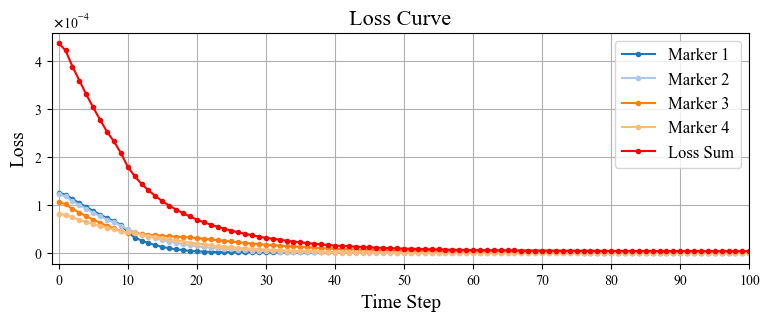

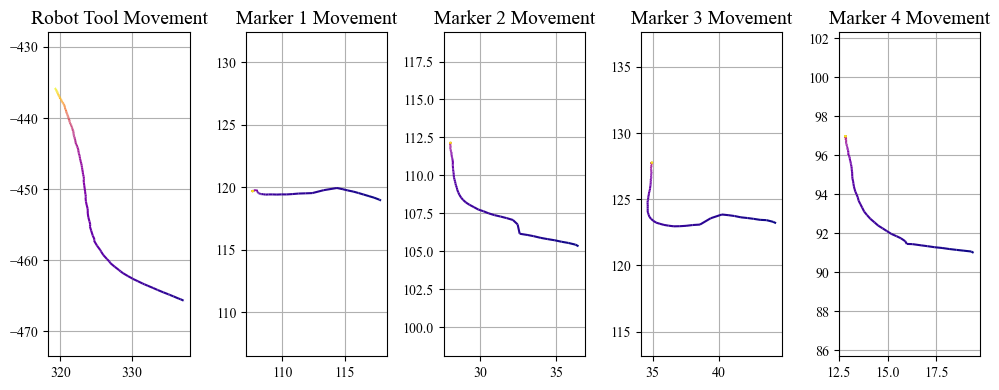

In [71]:
plot_loss_and_traj(loss_np, ur_data, dot_soft_np)

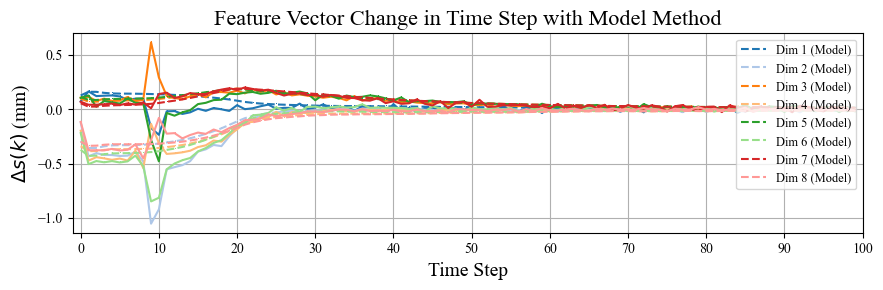

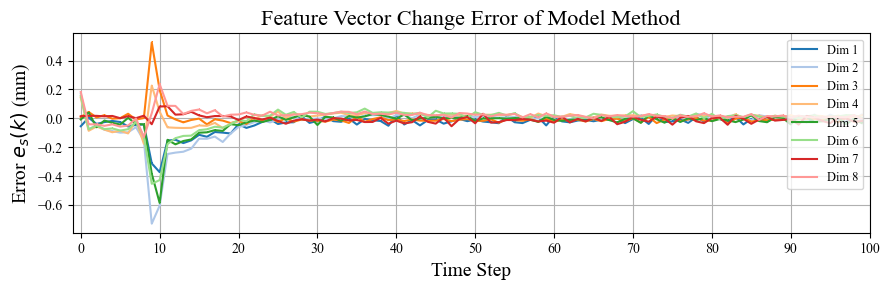

In [68]:
colors = plt.cm.tab20.colors
plot_step_num = 100

fig1 = plt.figure(figsize=(9, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig1)

axs_data = fig1.add_subplot(gs[0, :])
for i in range(2*POINTS_NUM):
    axs_data.plot(delta_pos[1:plot_step_num+1, i]*1000, marker=',', linestyle='-', color=colors[i % len(colors)])#, label=f'Dim {i+1}')
    axs_data.plot(delta_pos_model[1:plot_step_num+1, i]*1000, marker=',', linestyle='--', color=colors[i % len(colors)], label=f'Dim {i+1} (Model)')
axs_data.set_title('Feature Vector Change in Time Step with Model Method', fontsize=16, fontname='Times New Roman')
axs_data.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_data.set_ylabel('$\Delta s(k)$ (mm)', fontsize=14, fontname='Times New Roman')
axs_data.xaxis.set_major_locator(MultipleLocator(10))
axs_data.set_xlim([-1, plot_step_num])
axs_data.grid(True)
axs_data.legend(loc='upper right', fontsize=9)

plt.tight_layout()

fig2 = plt.figure(figsize=(9, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig2)
axs_error = fig2.add_subplot(gs[0, :])
for i in range(2*POINTS_NUM):
    axs_error.plot(delta_pos[1:plot_step_num+1, i]*1000 - delta_pos_model[1:plot_step_num+1, i]*1000, marker=',', linestyle='-', color=colors[i % len(colors)], label=f'Dim {i+1}')
axs_error.set_title('Feature Vector Change Error of Model Method', fontsize=16, fontname='Times New Roman')
axs_error.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_error.set_ylabel('Error $e_s(k)$ (mm)', fontsize=14, fontname='Times New Roman')
axs_error.xaxis.set_major_locator(MultipleLocator(10))
axs_error.set_xlim([-1, plot_step_num])
axs_error.grid(True)
axs_error.legend(loc='upper right', fontsize=9)
    
plt.tight_layout()